(example_eos_in_ml)=

# Impact of Effects of Site in Machine learning.
EoS can have two rather opposite effects to ML pipelines.

- The first effect is to **hinder** the real true signal. In this cases, the ML model have harder time to find the true signal, thus removing EoS should *improve* our classification, as the signal-to-noise ratio should improve.

- The second effect is to **confound** the true signal. In this cases, the ML model can *use* the EoS signal to fraudulently improve the performance, as the predictions will not be based on true biological signal but rather on site effects. In such cases, removing the EoS will *reduce* the model's performance. 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

from uniharmony import verbosity
from uniharmony.datasets import make_multisite_classification
from uniharmony.plot import plot_decision_boundary_2d


sns.set_theme(style="whitegrid")
verbosity("warning")

clf = LogisticRegression()
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

### First, lets create an example without EoS and classes balanced across site.

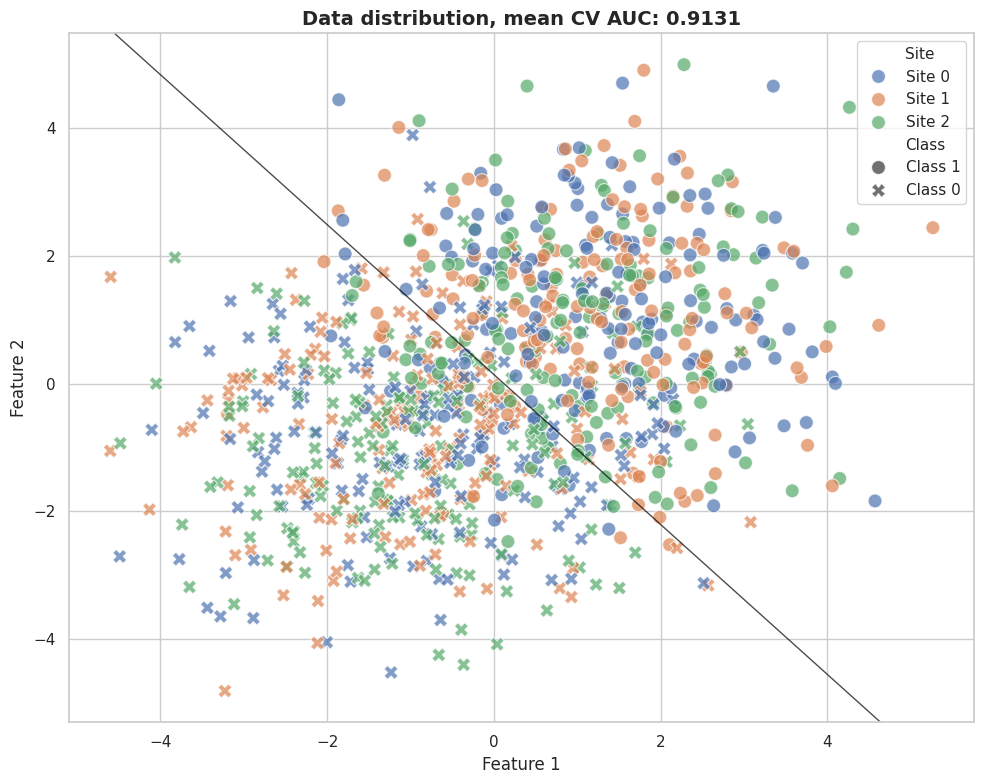

In [2]:
X, y, sites = make_multisite_classification(
    n_sites=3,
    n_features=2,
    signal_strength=2,
    site_effect_strength=0,
)
# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)
# Perform 10-fold stratified cross-validation
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# Plot with site as hue and class as style
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)
ax.set_title(f"Data distribution, mean CV AUC: {scores.mean():.4f}", fontsize=14, fontweight="bold")

plt.tight_layout()

# Fit the model and plot the decision boundary,
# this is just for visualization purposes, the real evaluation was be done with cross-validation
clf.fit(X, y)
plot_decision_boundary_2d(ax, clf)

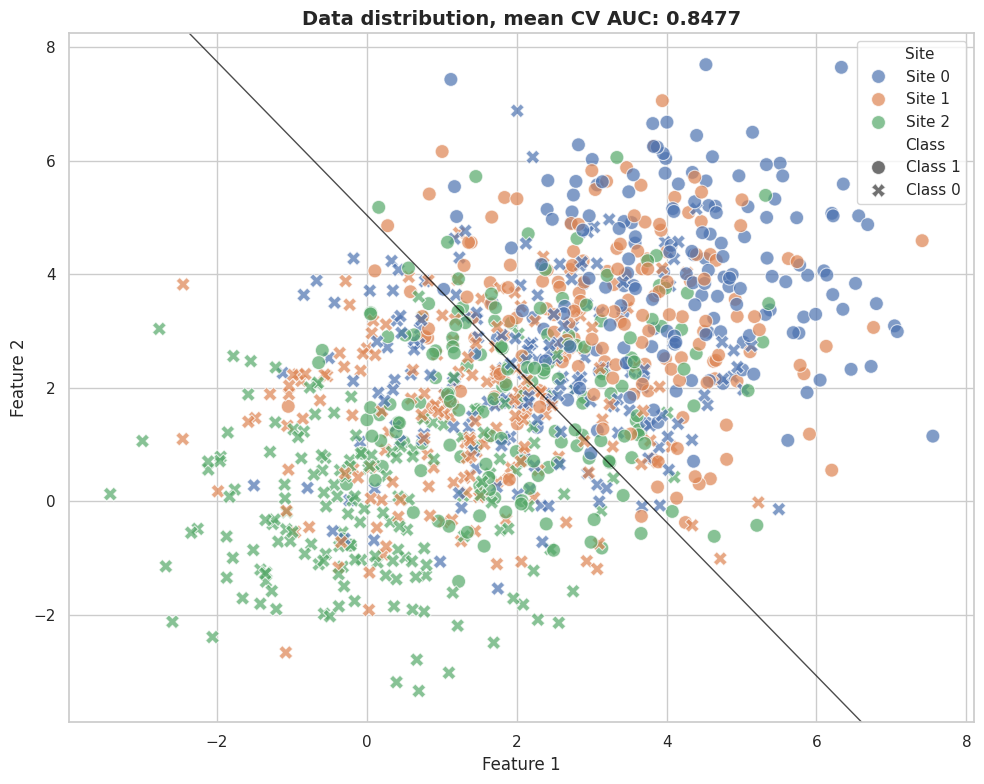

In [3]:
X, y, sites = make_multisite_classification(
    n_sites=3,
    n_features=2,
    signal_strength=2,
    site_effect_strength=4,
)


# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# Plot with site as hue and class as style
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)

ax.set_title(f"Data distribution, mean CV AUC: {scores.mean():.4f}", fontsize=14, fontweight="bold")

plt.tight_layout()

# Fit the model and plot the decision boundary,
# this is just for visualization purposes, the real evaluation was be done with cross-validation
clf.fit(X, y)
plot_decision_boundary_2d(ax, clf)

We don't have real signal, and the classes are equally distributed across sites
Mean accuracy: 0.5270


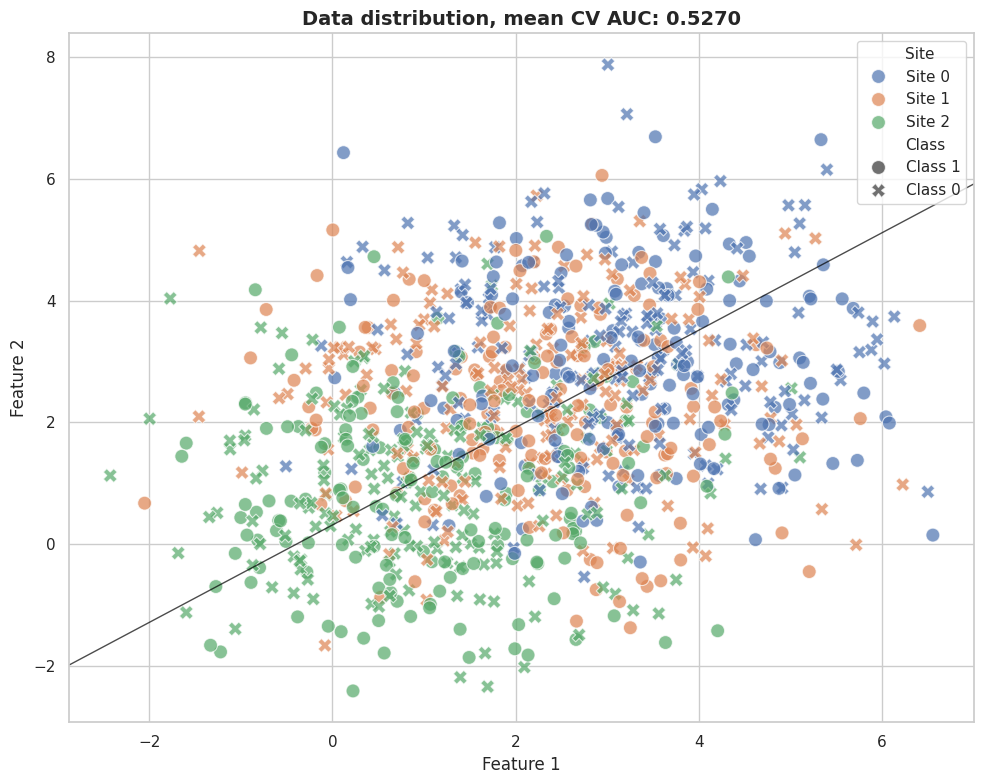

In [4]:
X, y, sites = make_multisite_classification(
    n_sites=3,
    n_features=2,
    signal_strength=0,
    site_effect_strength=4,
)

# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)

scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

# Plot with site as hue and class as style
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)
ax.set_title(f"Data distribution, mean CV AUC: {scores.mean():.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()

# Fit the model and plot the decision boundary,
# this is just for visualization purposes, the real evaluation was be done with cross-validation
clf.fit(X, y)
plot_decision_boundary_2d(ax, clf)

print("We don't have real signal, and the classes are equally distributed across sites")
print(f"Mean accuracy: {scores.mean():.4f}")

We don't have real signal, but now classes are not equally distributed across sites.
The ML models might pick up on the site differences to fraudulently perform the task.
Mean accuracy: 0.7593


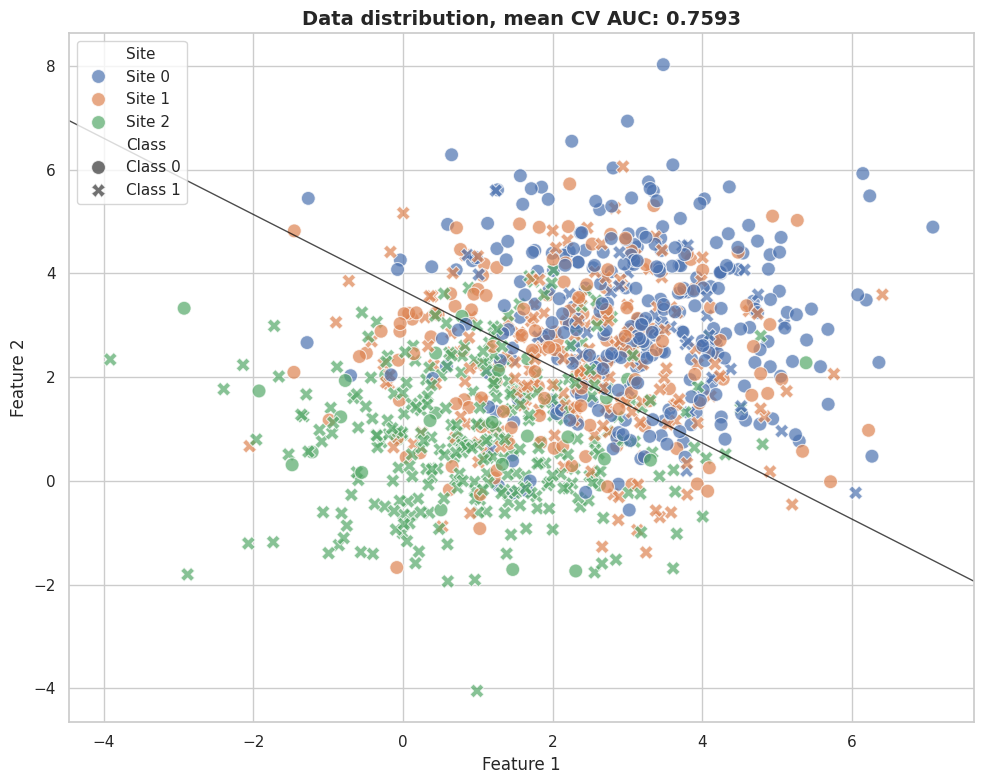

In [5]:
X, y, sites = make_multisite_classification(
    n_sites=3,
    n_features=2,
    signal_strength=0,
    site_effect_strength=4,
    balance_per_site=[0.1, 0.5, 0.9],
)

# Test the visualization


# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

# Plot with site as hue and class as style
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)
ax.set_title(f"Data distribution, mean CV AUC: {scores.mean():.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()

# Fit the model and plot the decision boundary,
# this is just for visualization purposes, the real evaluation was be done with cross-validation
clf.fit(X, y)
plot_decision_boundary_2d(ax, clf)
print("We don't have real signal, but now classes are not equally distributed across sites.")
print("The ML models might pick up on the site differences to fraudulently perform the task.")
print(f"Mean accuracy: {scores.mean():.4f}")

We don't have real signal, nor site effects. Even with class imbalance across sites, there is nothing to pick up.
Mean accuracy: 0.5449


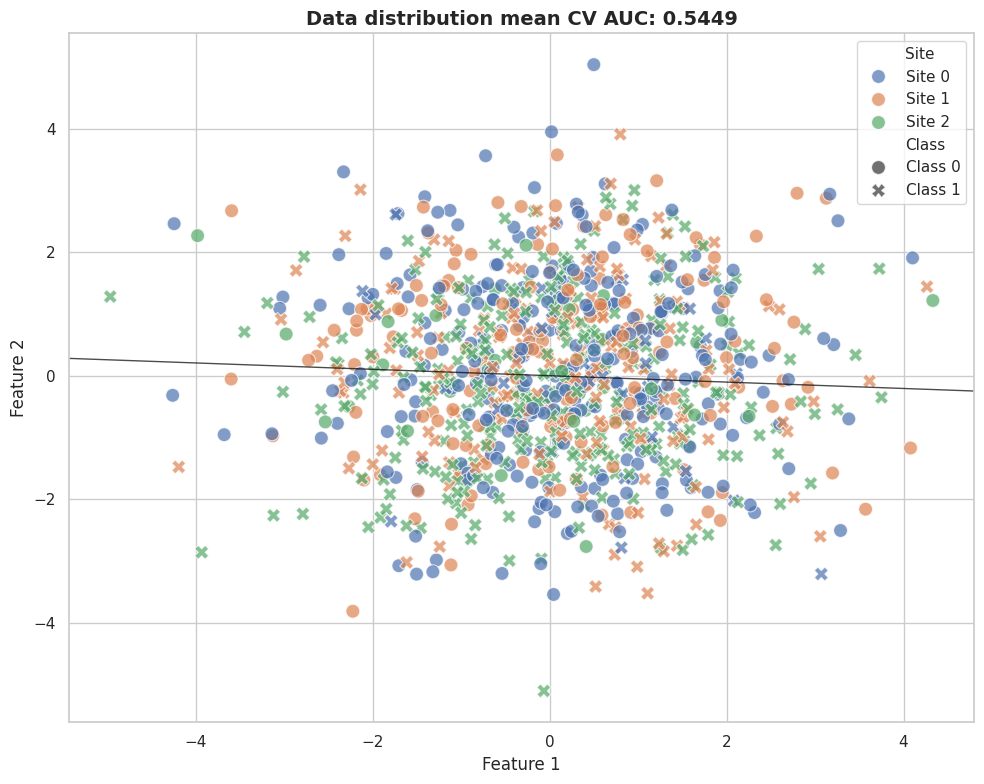

In [6]:
X, y, sites = make_multisite_classification(
    n_sites=3,
    n_features=2,
    signal_strength=0,
    site_effect_strength=0,
    balance_per_site=[0.1, 0.5, 0.9],
)

# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# Plot with site as hue and class as style
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)

ax.set_title(f"Data distribution mean CV AUC: {scores.mean():.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()

# Fit the model and plot the decision boundary,
# this is just for visualization purposes, the real evaluation was be done with cross-validation
clf.fit(X, y)
plot_decision_boundary_2d(ax, clf)
print("We don't have real signal, nor site effects. Even with class imbalance across sites, there is nothing to pick up.")
print(f"Mean accuracy: {scores.mean():.4f}")